First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2 



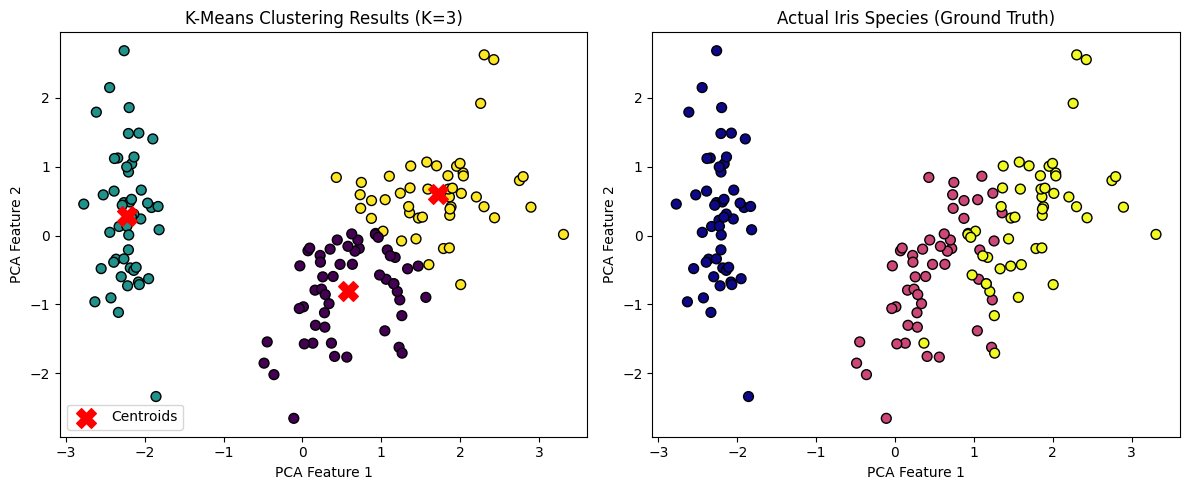

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
print("First 5 rows of the dataset:")
print(df.head(), "\n")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)


labels = kmeans.labels_
centroids = kmeans.cluster_centers_


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(centroids)


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", edgecolor="k", s=50
)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids",
)
plt.title("K-Means Clustering Results (K=3)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=y, cmap="plasma", edgecolor="k", s=50
)
plt.title("Actual Iris Species (Ground Truth)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")

plt.tight_layout()
plt.show()